In [2]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook'])

/home/daneel/gitrepos/mdanalysis/package/MDAnalysis/lib/_distopia.py:45: RuntimeWarning: Install 'distopia>=0.2.0,<0.3.0' to be used with this release of MDAnalysis. Your installed version of distopia >=0.3.0 will NOT be used.
  warnings.warn(


## Principal Component Analysis 

We will do the PCA using `gromacs` tools. Tentative comparison yields quantitatively better results for `gromacs` than `MDAnalysis`.

***Notabene*** MUST USE BACKBONE AND LIGAND AS SELECTIONS, SINCE WE NEED TO LOOK AT LIGAND CONFORMATIONAL CHANGES AS WELL.


(0.0, 10.0)

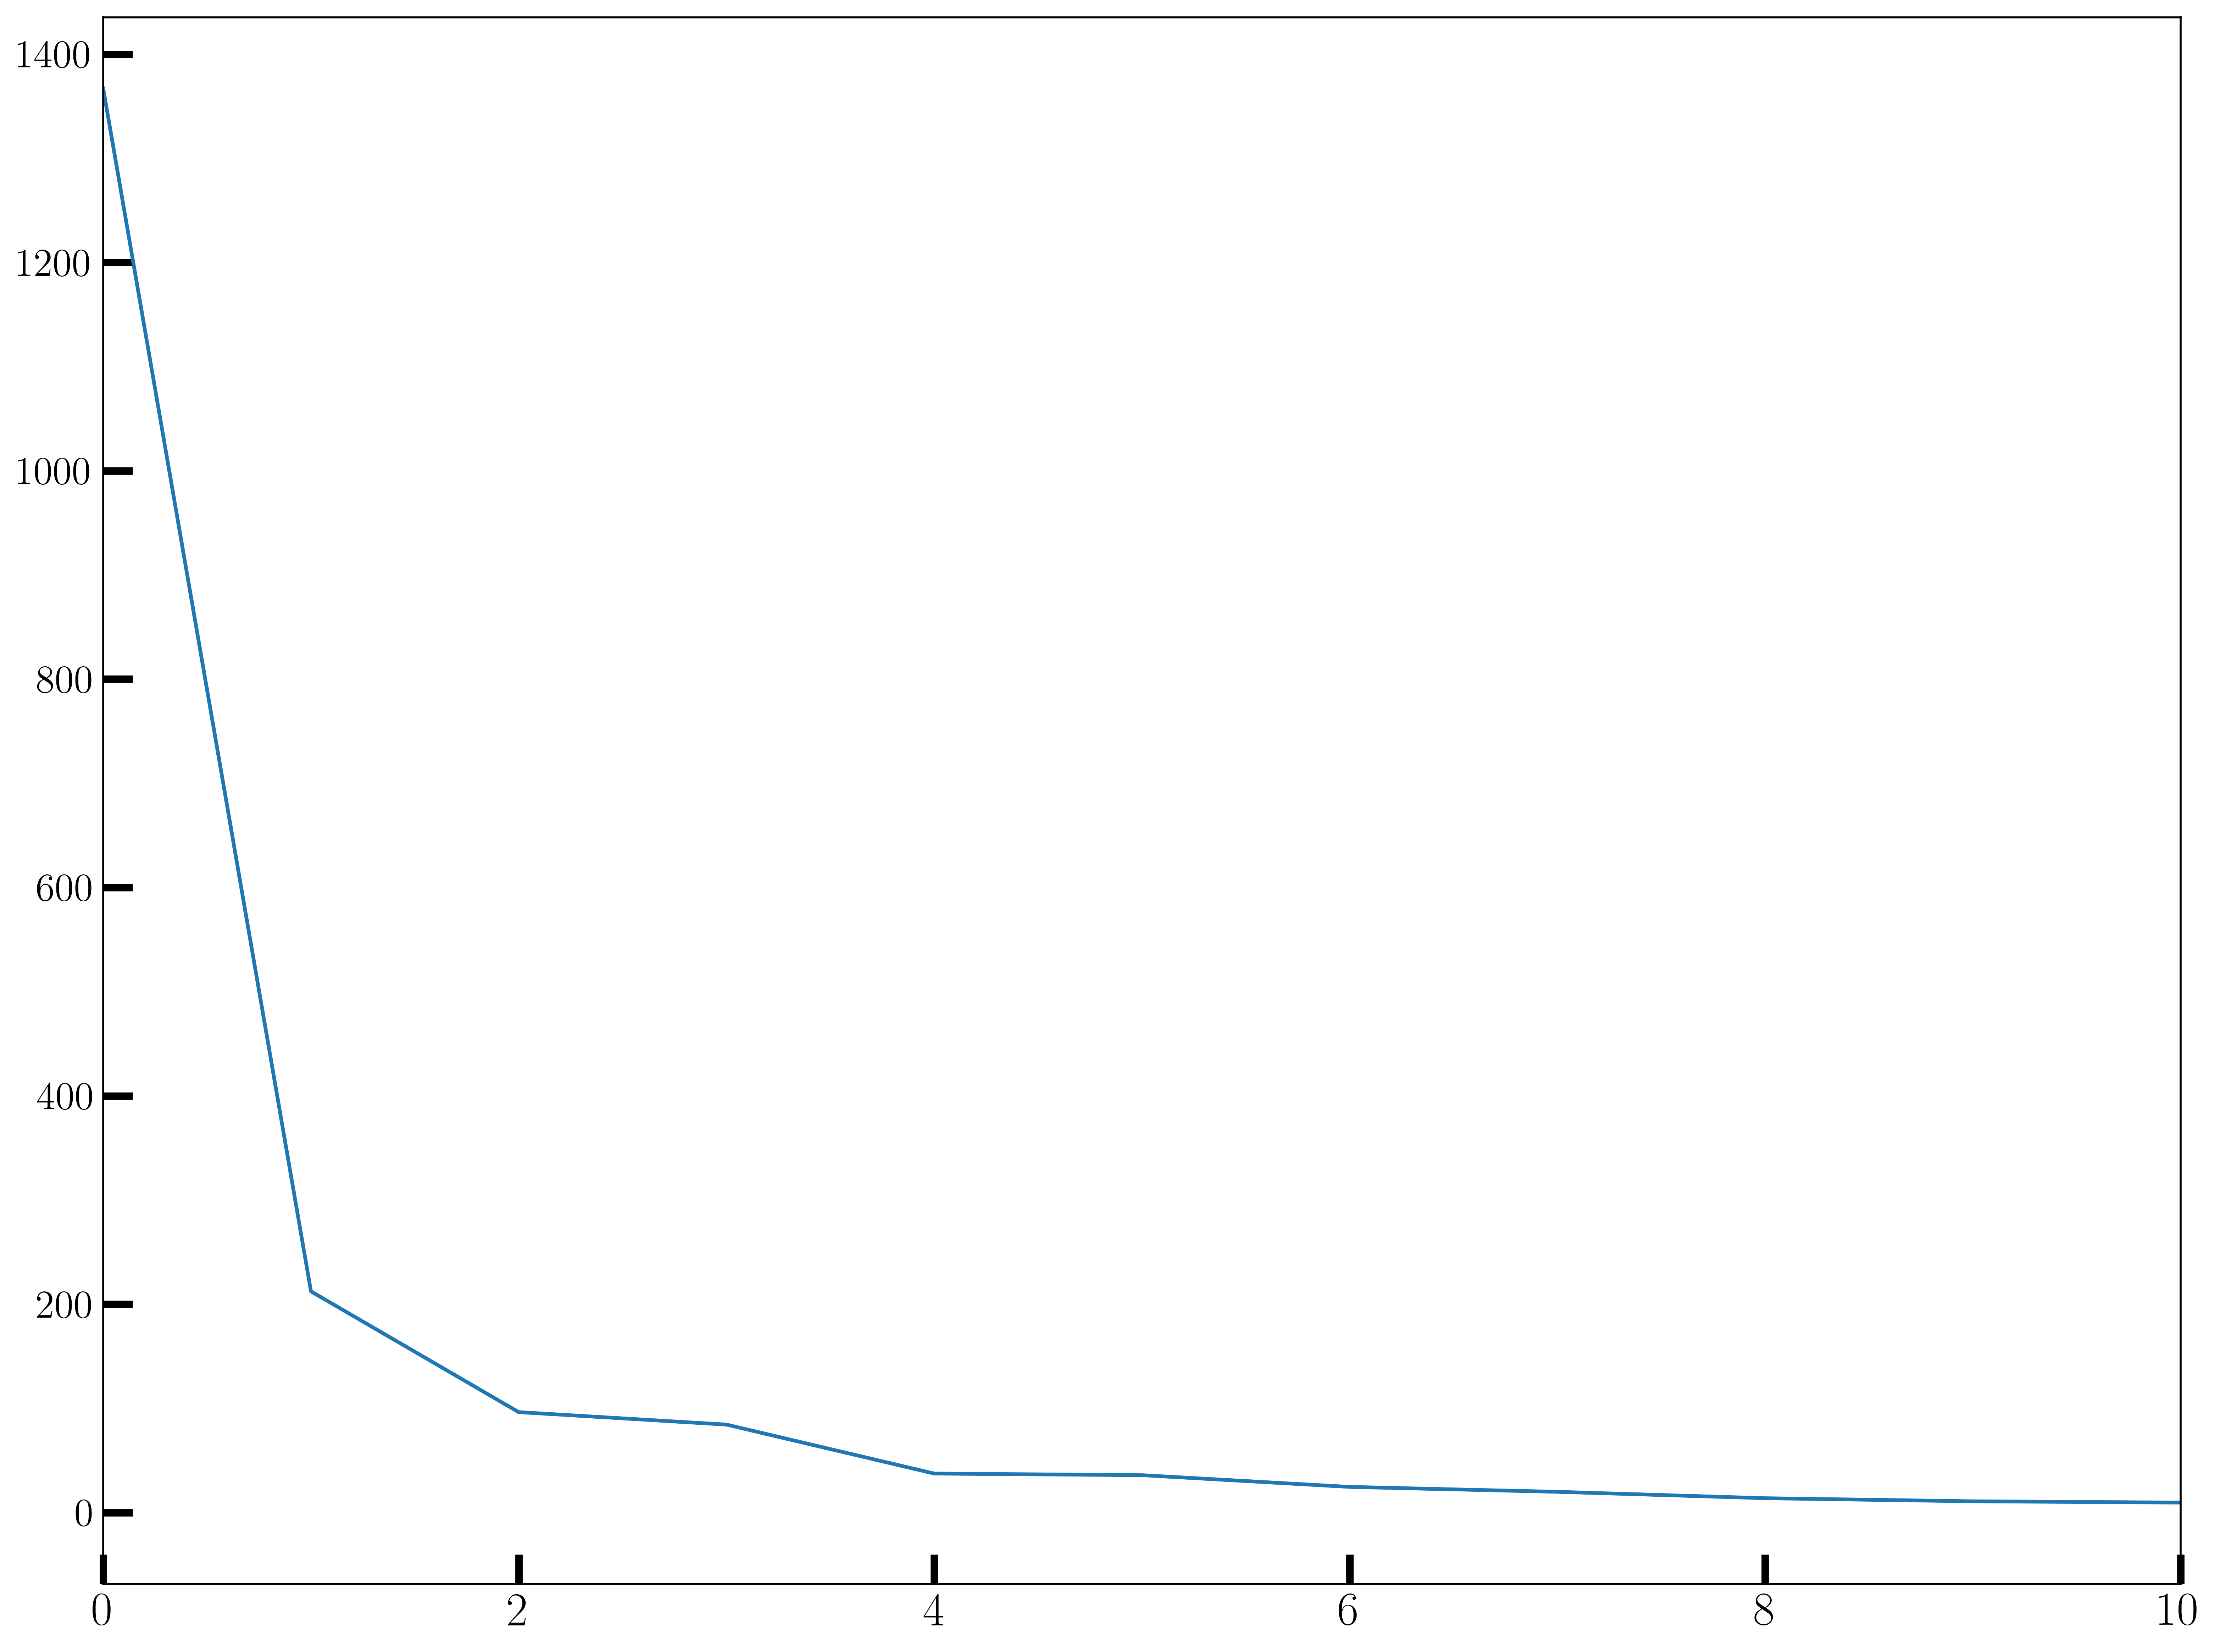

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
complex = "cuedc2-erg"

# Unpack directly into separate arrays
eigenvector_indices, eigenvalues = np.loadtxt(
    "pca/cuedc2-erg/prod_cuedc2_erg_eigenvalues.xvg", 
    comments=('@', '#'), 
    unpack=True
)

plt.plot(eigenvalues)
plt.xlim(0,10)


In [18]:
PC12_1, PC12_2, free_energy_12 = np.loadtxt("pca/cuedc2-erg/prod_cuedc2_erg_FEL12.dat", unpack=True)
time, pc1_data, pc2_data = np.loadtxt("pca/cuedc2-erg/prod_cuedc2_erg_pc1pc2.xvg", unpack=True)

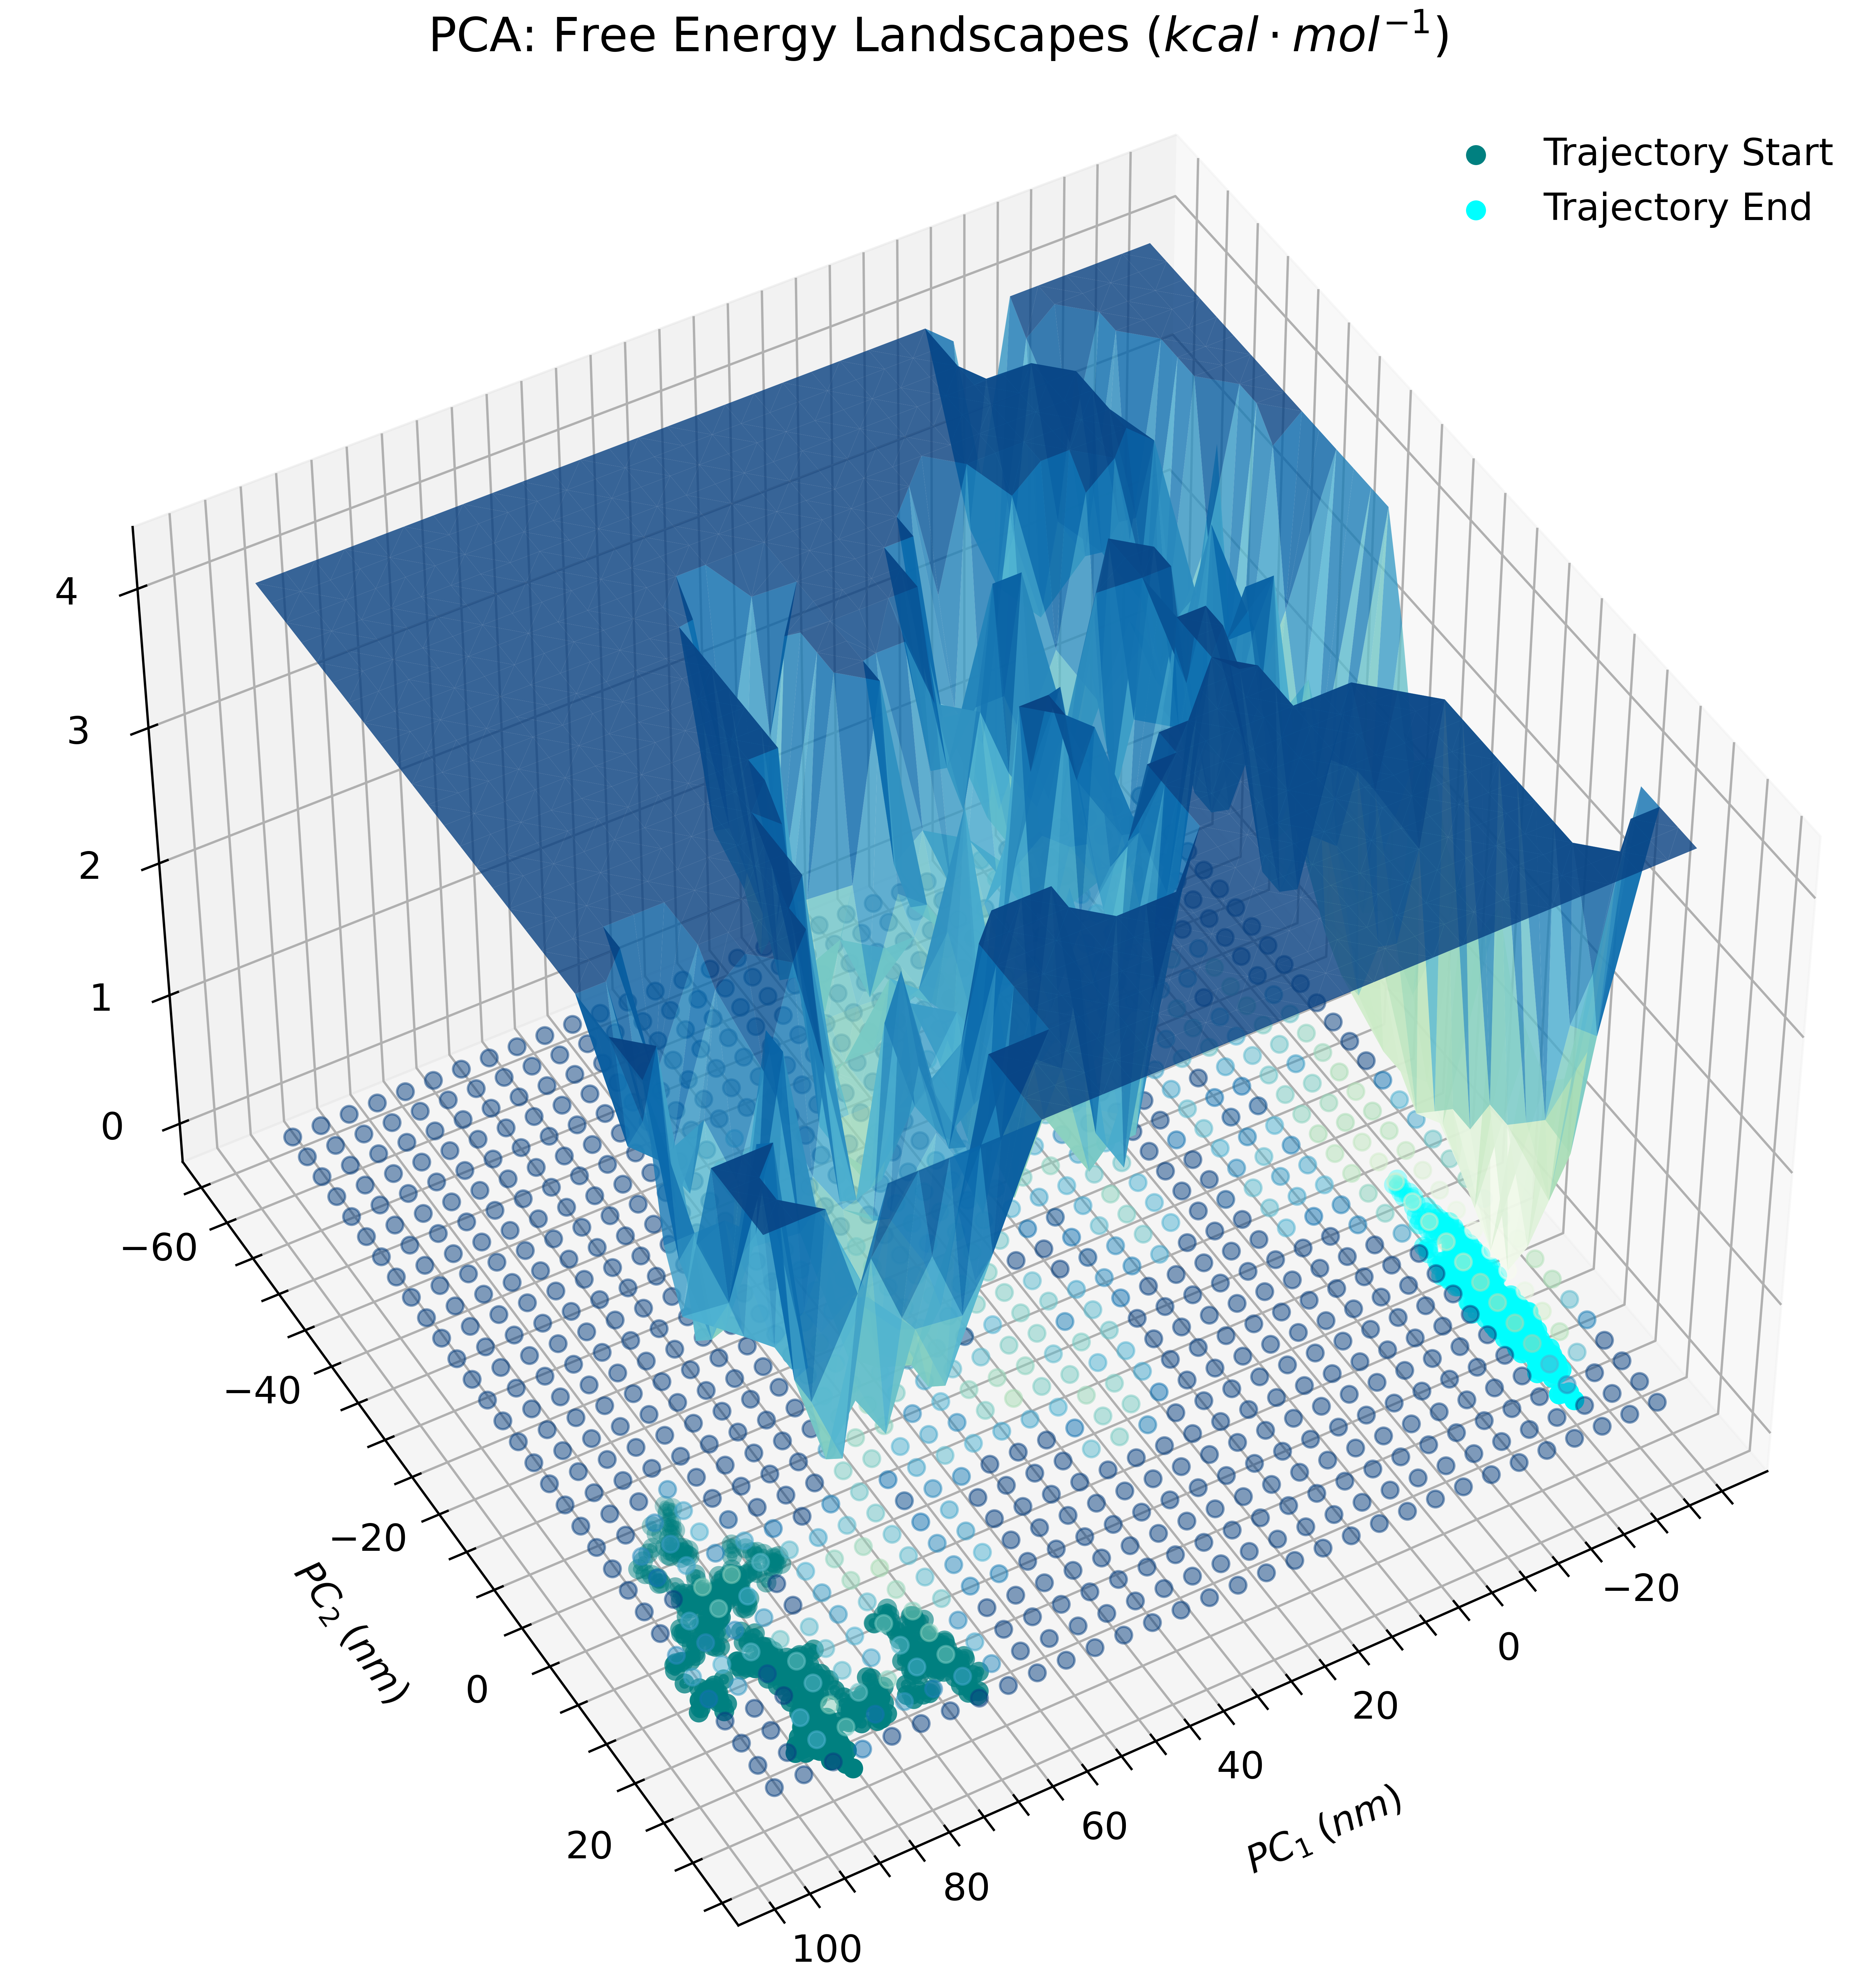

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import scienceplots

import matplotlib.pyplot as plt
size = np.array([40,12])
plt.style.use(['science','notebook'])
fig = plt.figure(figsize=size)
fig.suptitle(r'PCA: Free Energy Landscapes $\left(kcal\cdot mol^{-1}\right)$', fontsize=20)
# First subplot: free_energy_12 vs PC12
ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.plot_trisurf(PC12_1, PC12_2, free_energy_12/4.184, cmap='GnBu', alpha=0.8)
ax1.set_xlabel(r'$PC_1\; (nm)$', labelpad=20)
ax1.set_ylabel(r'$PC_2\;(nm)$', labelpad=20)
ax1.scatter(PC12_1, PC12_2, c=free_energy_12, cmap='GnBu', s=50, alpha=0.5)
ax1.scatter(pc1_data[0:500], pc2_data[0:500], 0, color='teal', linewidth=4, label='Trajectory Start')
ax1.scatter(pc1_data[-500:-1], pc2_data[-500:-1], 0, color='cyan', linewidth=4, label='Trajectory End')
ax1.legend()

ax1.yaxis.set_tick_params(pad=10)
ax1.view_init(elev=45, azim=60)
ax1.set_zticks([0, 1, 2, 3, 4])
ax1.zaxis.set_tick_params(pad=10)
#plt.savefig("pca-free-energy.svg", dpi=600)
plt.tight_layout()
plt.show()

The trajectory is definitely crossing a barrier.